# Exploratory Data analysis

In [2]:
import pandas as pd
import numpy as np
train = pd.read_csv(r"\Users\DIVYA PRIYA\Downloads\FInal_project1_AI_Banking\Data\Raw\train.csv")
train

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
...,...,...
9998,You provide support in what countries?,country_support
9999,What countries are you supporting?,country_support
10000,What countries are getting support?,country_support
10001,Are cards available in the EU?,country_support


In [3]:
test = pd.read_csv(r"\Users\DIVYA PRIYA\Downloads\FInal_project1_AI_Banking\Data\Raw\test.csv")
test

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3075,"If i'm not in the UK, can I still get a card?",country_support
3076,How many countries do you support?,country_support
3077,What countries do you do business in?,country_support
3078,What are the countries you operate in.,country_support


# Category distribution analysis

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64
category
card_arrival                        40
card_linking                        40
exchange_rate                       40
card_payment_wrong_exchange_rate    40
extra_charge_on_statement           40
                                    ..
cash_withdrawal_charge              40
card_about_to_expire                40
apple_pay_or_goo

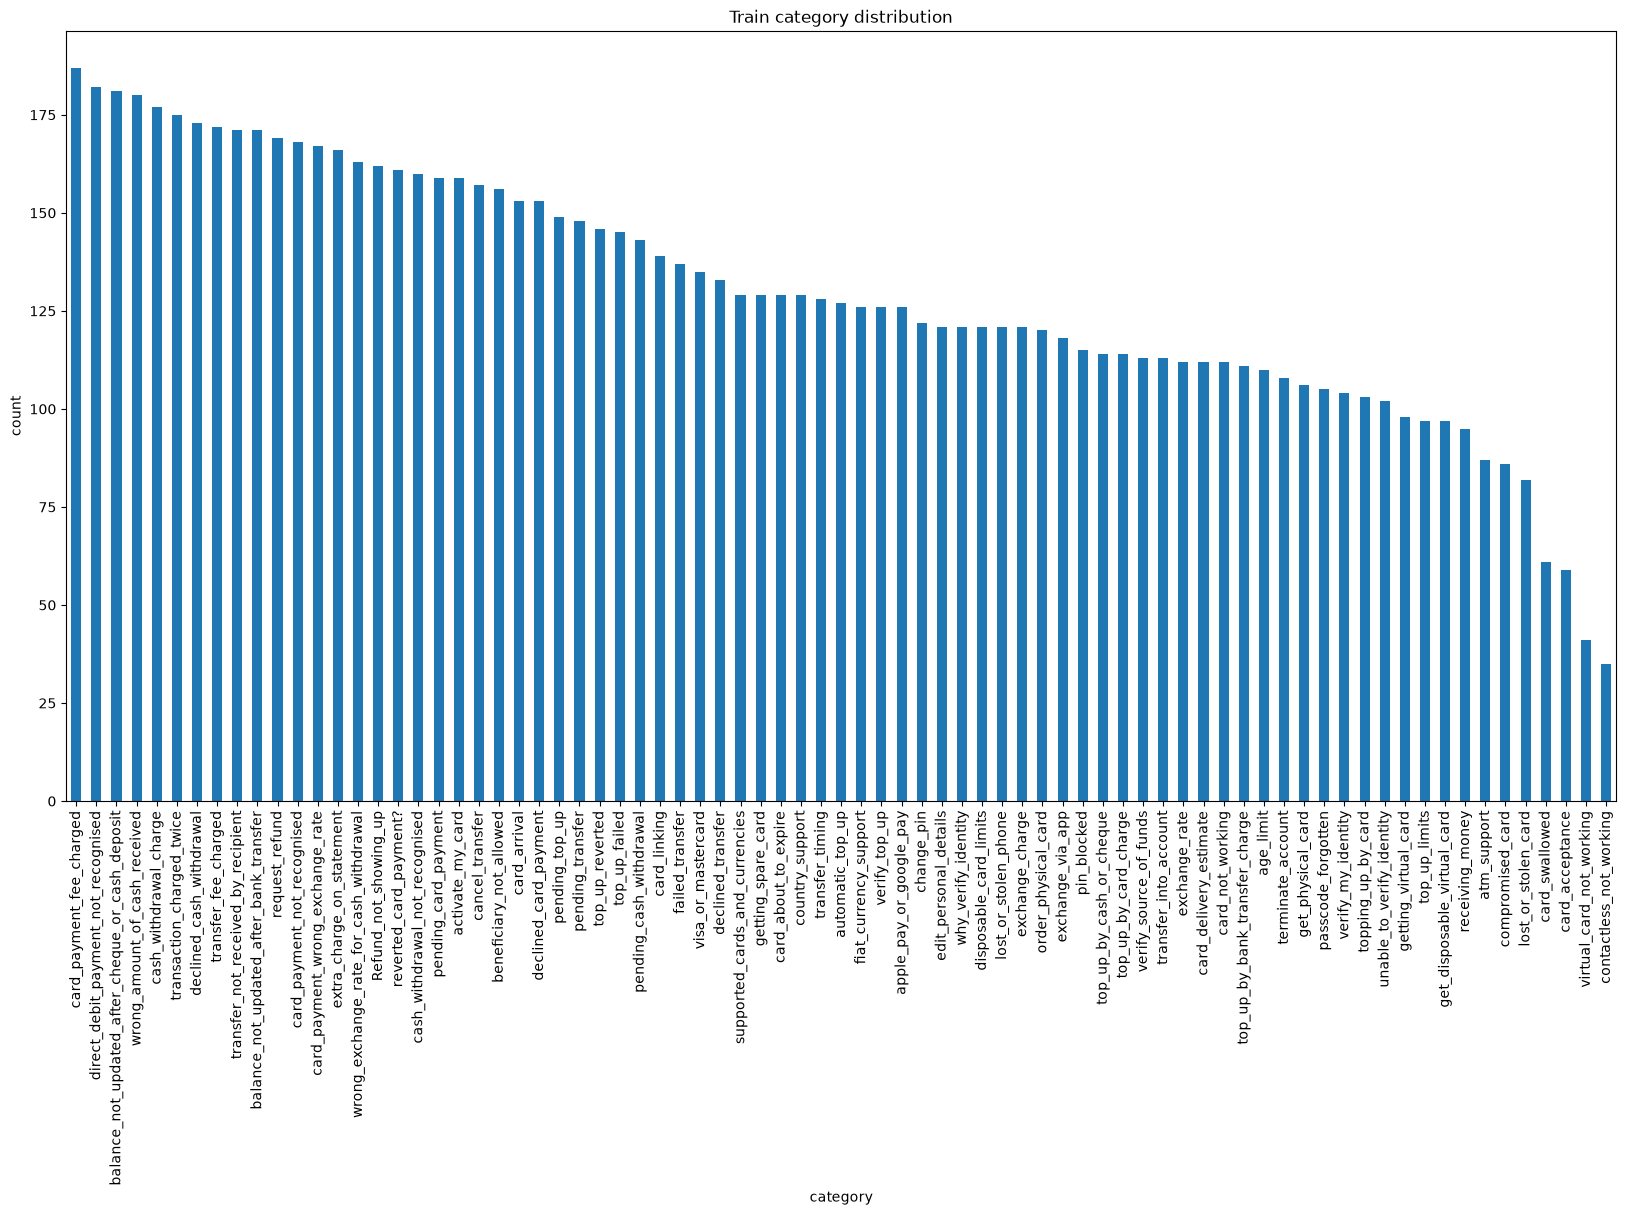

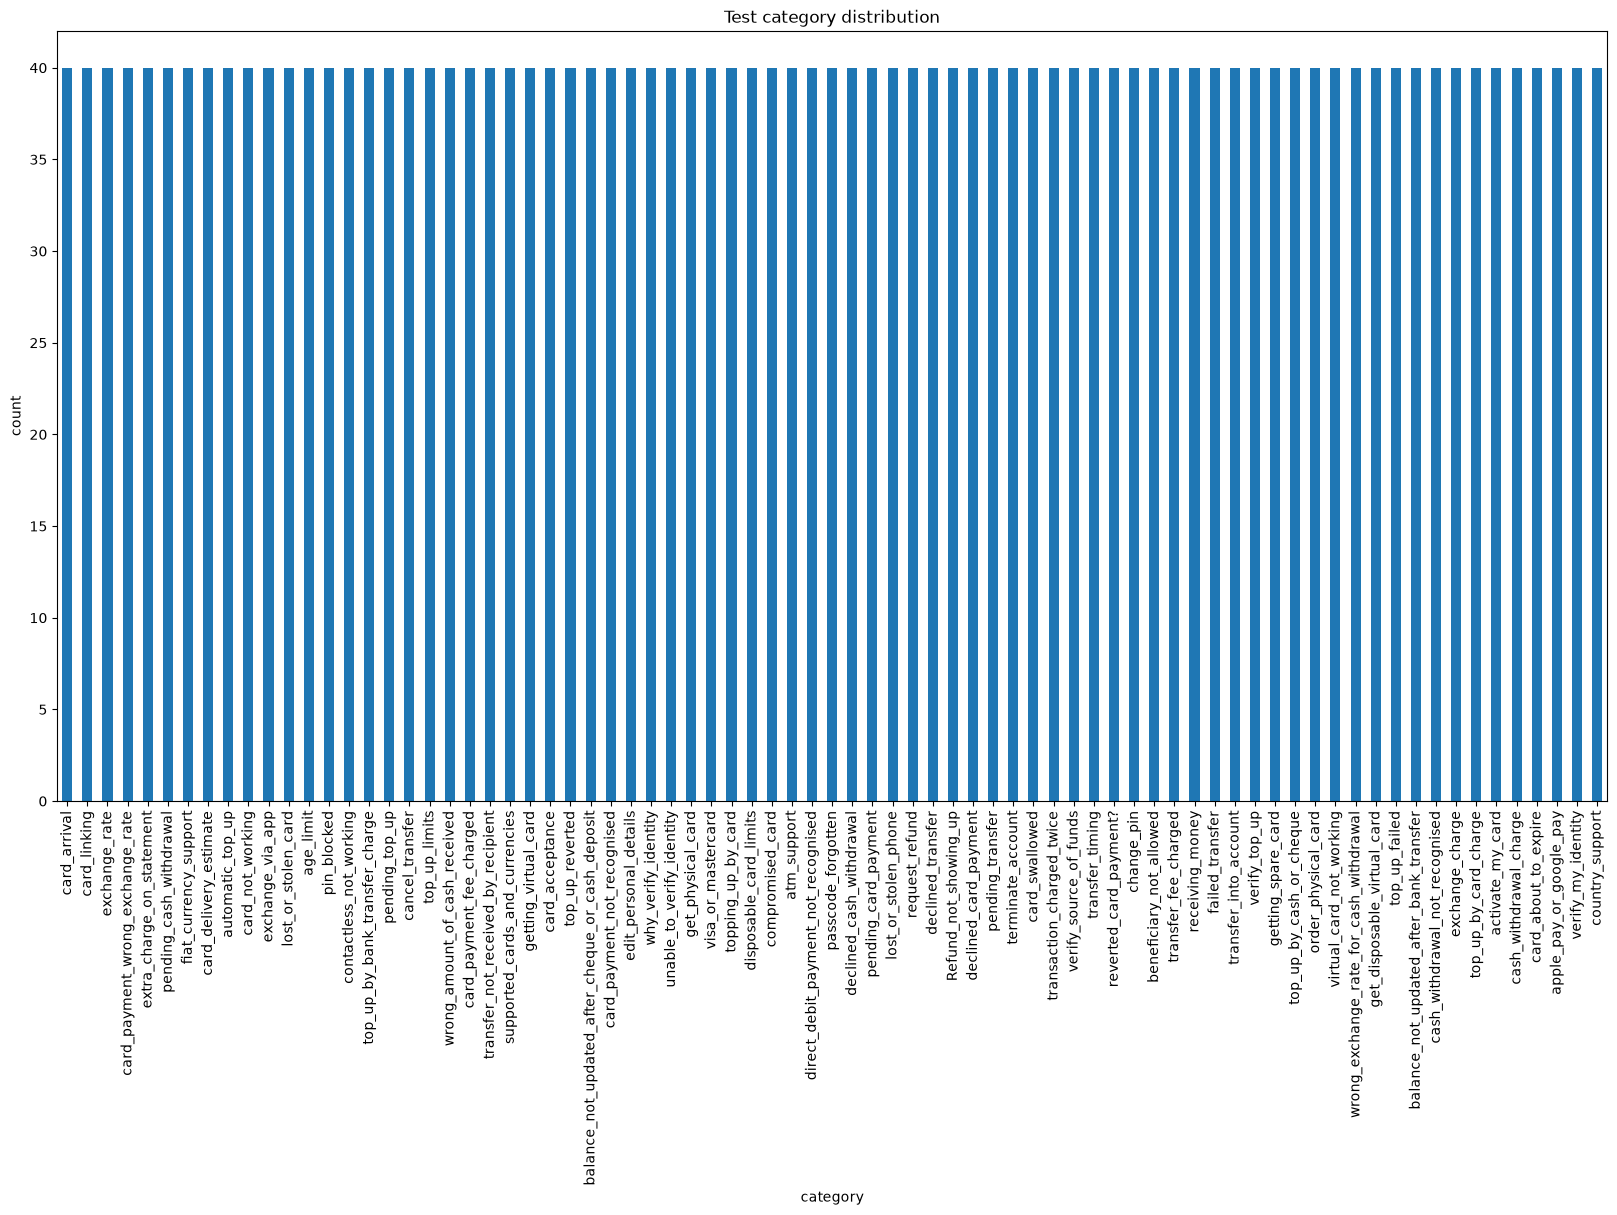

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

train_distribution = train['category'].value_counts()
print(train_distribution)
test_distribution = test['category'].value_counts()
print(test_distribution)

train_distribution.plot(kind='bar',figsize=(20,10),title='Train category distribution')
plt.ylabel('count')
plt.show()

test_distribution.plot(kind='bar',figsize=(20,10),title='Test category distribution')
plt.ylabel('count')
plt.show()

# Text length analysis

In [ ]:
%pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

train['char_len'] = train['text'].astype(str).apply(len)
train['word_len'] = train['text'].astype(str).apply(lambda x: len(x.split()))

test['char_len'] = test['text'].astype(str).apply(len) 
test['word_len'] = test['text'].astype(str).apply(lambda x: len(x.split()))

print("Train Text Length:")
print(train[['char_len','word_len']].describe())

print("\nTest Text Length:")
print(test[['char_len','word_len']].describe())



Train Text Length:
           char_len      word_len
count  10003.000000  10003.000000
mean      59.473758     11.949415
std       40.867901      7.891577
min       13.000000      2.000000
25%       36.000000      7.000000
50%       47.000000     10.000000
75%       64.000000     13.000000
max      433.000000     79.000000

Test Text Length:
          char_len     word_len
count  3080.000000  3080.000000
mean     54.232468    10.952597
std      34.658008     6.688180
min      13.000000     2.000000
25%      35.000000     7.000000
50%      45.000000     9.000000
75%      60.000000    12.000000
max     368.000000    69.000000


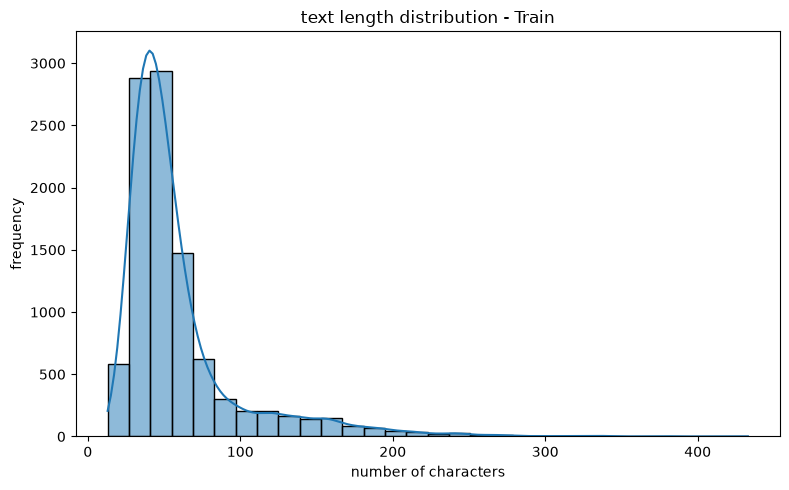

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(train['char_len'],bins=30,kde=True)
plt.title("text length distribution - Train")
plt.xlabel("number of characters")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

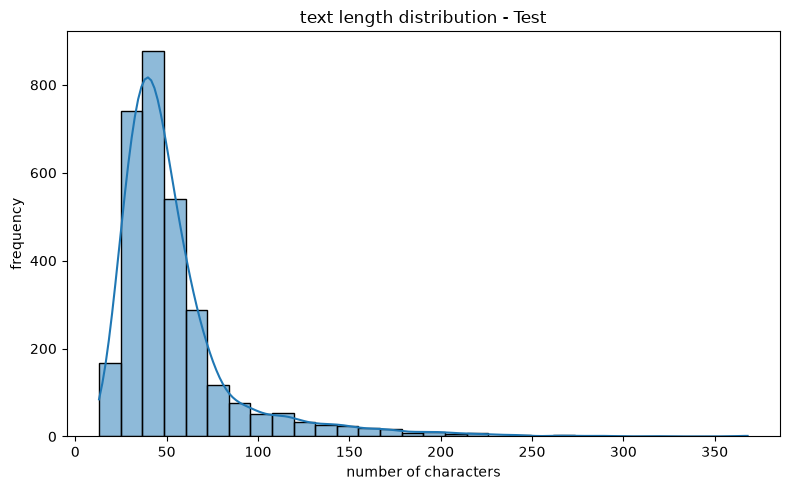

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(test['char_len'],bins=30,kde=True)
plt.title("text length distribution - Test")
plt.xlabel("number of characters")
plt.ylabel("frequency")

plt.tight_layout()
plt.show()

In [ ]:
# average text length by category - train
avg_len_category =(train.groupby("category")['char_len'].mean().sort_values(ascending=False))
print(avg_len_category)

category
transfer_not_received_by_recipient    91.567251
transfer_fee_charged                  89.627907
pending_cash_withdrawal               85.783217
transaction_charged_twice             84.125714
failed_transfer                       83.759124
                                        ...    
card_acceptance                       37.237288
atm_support                           36.873563
order_physical_card                   35.725000
top_up_limits                         35.082474
get_physical_card                     32.867925
Name: char_len, Length: 77, dtype: float64


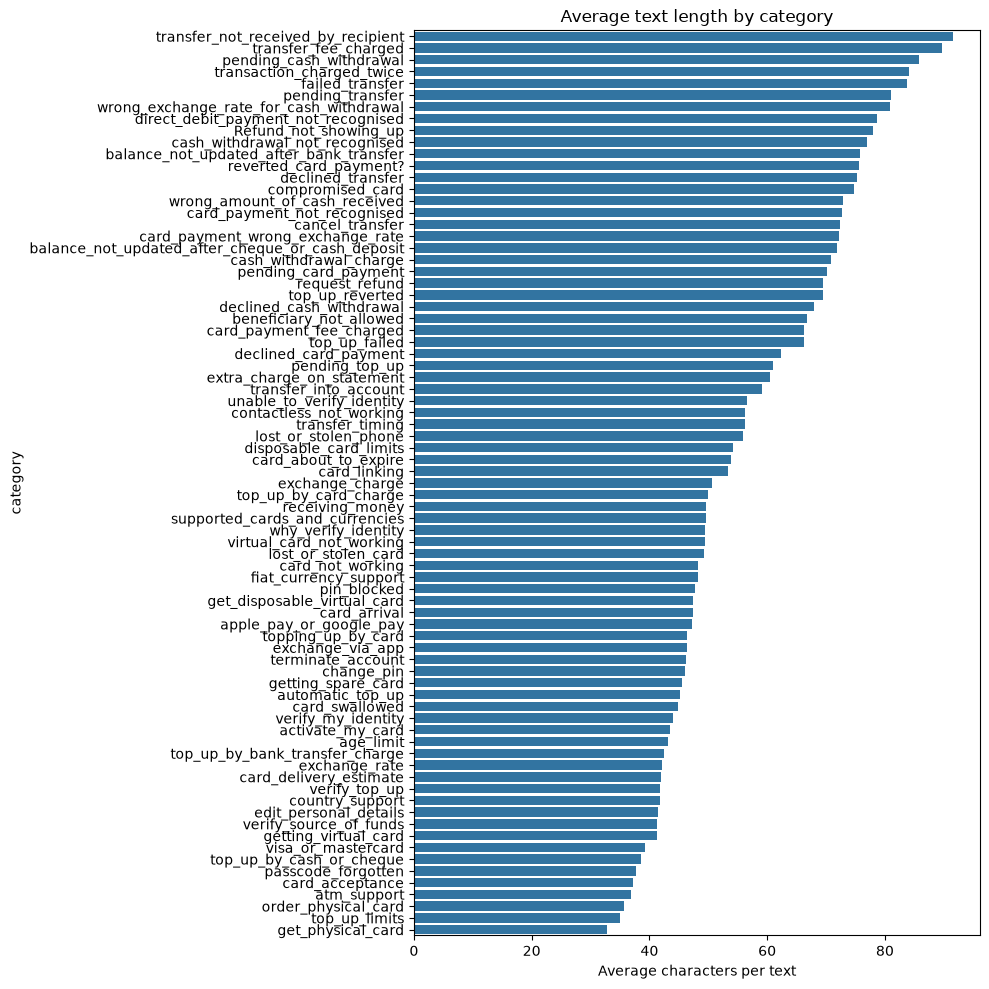

In [32]:
#average text length by category- graph

plt.figure(figsize=(10,10))
sns.barplot(x=avg_len_category.values,y=avg_len_category.index)

plt.title("Average text length by category")
plt.xlabel("Average characters per text")
plt.ylabel("category")

plt.tight_layout()
plt.show()

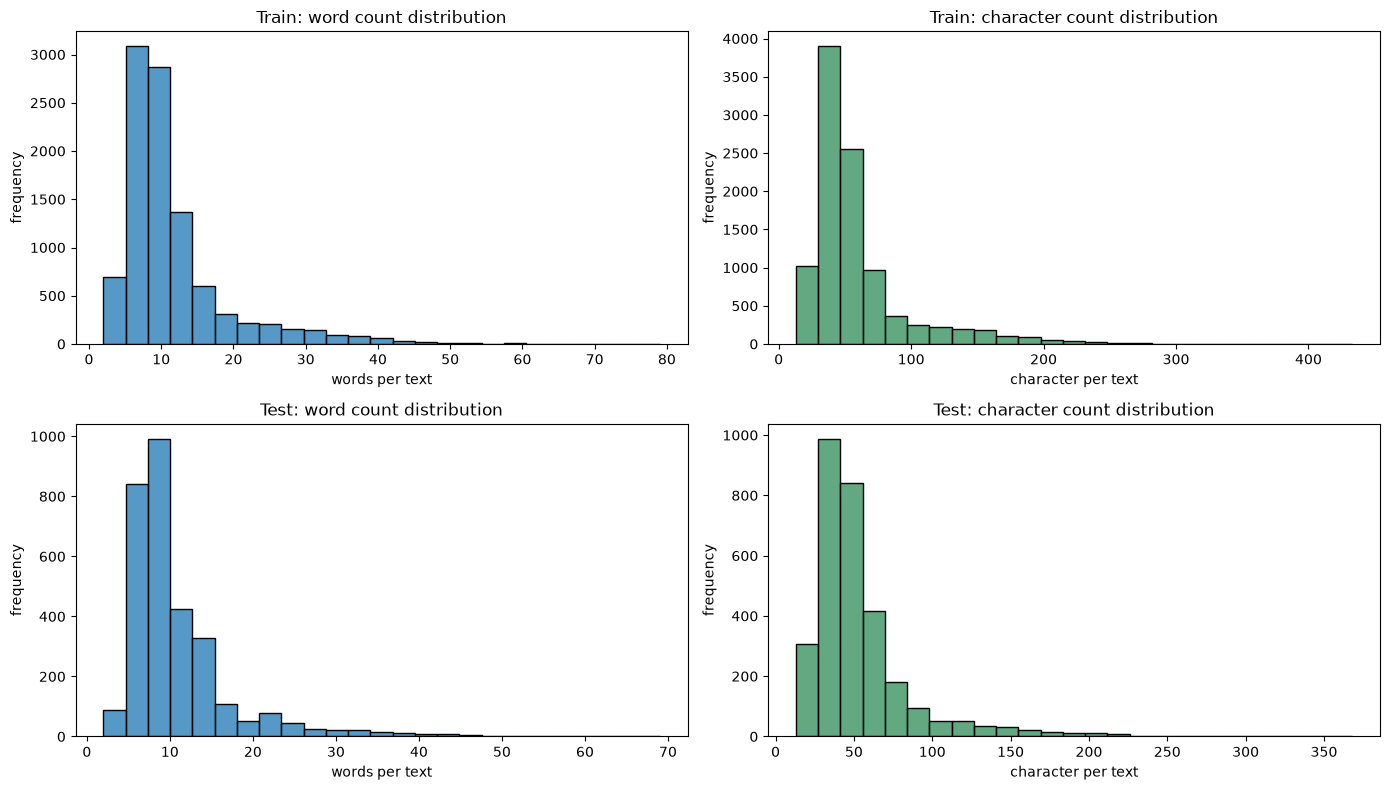

In [7]:
fig,axes =plt.subplots(2,2,figsize=(14,8))

#train - word length
sns.histplot(train['word_len'],bins=25,ax=axes[0,0])
axes[0,0].set_title('Train: word count distribution')
axes[0,0].set_xlabel('words per text')
axes[0,0].set_ylabel('frequency')
#train - char length
sns.histplot(train['char_len'],bins=25,ax=axes[0,1],color='seagreen',edgecolor='black')
axes[0,1].set_title('Train: character count distribution')
axes[0,1].set_xlabel('character per text')
axes[0,1].set_ylabel('frequency') 

#test - word length
sns.histplot(test['word_len'],bins=25,ax=axes[1,0])
axes[1,0].set_title('Test: word count distribution')
axes[1,0].set_xlabel('words per text')
axes[1,0].set_ylabel('frequency')
#test - char length
sns.histplot(test['char_len'],bins=25,ax=axes[1,1],color='seagreen',edgecolor='black')
axes[1,1].set_title('Test: character count distribution')
axes[1,1].set_xlabel('character per text')
axes[1,1].set_ylabel('frequency')

plt.tight_layout()
plt.show()


In [ ]:
# word count - Train vs test
train['word_count'] = train['text'].str.split().str.len()
test['word_count'] = test['text'].str.split().str.len()

print("Average words in train:",train['word_count'].mean())
print("Average words in test:",test['word_count'].mean())

Average words in train: 11.949415175447365
Average words in test: 10.952597402597403


In [34]:
avg_words_category =(train.groupby("category")['word_count'].mean().sort_values(ascending=False))

print(avg_words_category)

category
transfer_not_received_by_recipient     17.549708
transfer_fee_charged                   17.395349
pending_cash_withdrawal                16.531469
failed_transfer                        15.992701
direct_debit_payment_not_recognised    15.989011
                                         ...    
top_up_limits                           7.742268
get_physical_card                       7.707547
passcode_forgotten                      7.695238
atm_support                             7.689655
card_acceptance                         7.474576
Name: word_count, Length: 77, dtype: float64


In [38]:
# check shortest and longest texts
print("shortest train text:")
print(train.loc[train['char_len'].idxmin(),'text'])

print("Longest train text:")
print(train.loc[train['char_len'].idxmax(),'text'])


shortest train text:
Can I top up?
Longest train text:
Hearing back from us regarding your important verification results may take 10 minutes to one hour time.  If verification results do fail, double-check to make sure all of your images are clear --  make sure your photos have no glare or blurring. Note: These photos need to be readable as well.  You also need to be 18 years of age or older.  You must be a resident of Switzerland or the European Economic Area to open a new account.


# Data quality analysis

In [39]:
print("Train Data quality")

print("Empty strings:",(train['text'].str.strip() == ' ').sum())
print("very short texts(<3 chars):",(test['char_len'] < 3).sum())

print("Test Data quality")

print("Empty strings:",(test['text'].str.strip() == ' ').sum())
print("very short texts(<3 chars):",(test['char_len'] < 3).sum())

Train Data quality
Empty strings: 0
very short texts(<3 chars): 0
Test Data quality
Empty strings: 0
very short texts(<3 chars): 0


In [14]:
train['category'].value_counts()
train['category'].value_counts(normalize=True) * 100
test['category'].value_counts()
test['category'].value_counts(normalize=True) * 100

rare_classes = train['category'].value_counts()
rare_classes[rare_classes < 10]

rare_classes = test['category'].value_counts()
rare_classes[rare_classes < 10]

Series([], Name: count, dtype: int64)

In [15]:
print(train['word_len'].describe())

train[train['word_len'] > train['word_len'].quantile(0.99)]
train[train['word_len'] < 2]

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: word_len, dtype: float64


,text,category,char_len,word_len


In [41]:
print("number of unique categories in train:", train['category'].nunique())

print("\ncategories:")
print(train['category'].nunique())

number of unique categories in train: 77

categories:
77


In [43]:
print("duplicated texts in train:",train['text'].duplicated().sum())
print("duplicated texts in test:",test['text'].duplicated().sum())


duplicated texts in train: 0
duplicated texts in test: 0


# category imbalance analysis

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
                                                   ... 
lost_or_stolen_card                                  82
card_swallowed                                       61
card_acceptance                                      59
virtual_card_not_working                             41
contactless_not_working                              35
Name: count, Length: 77, dtype: int64
category
card_payment_fee_charged                            1.87
direct_debit_payment_not_recognised                 1.82
balance_not_updated_after_cheque_or_cash_deposit    1.81
wrong_amount_of_cash_received                       1.80
cash_withdrawal_charge                              1.77
                                           

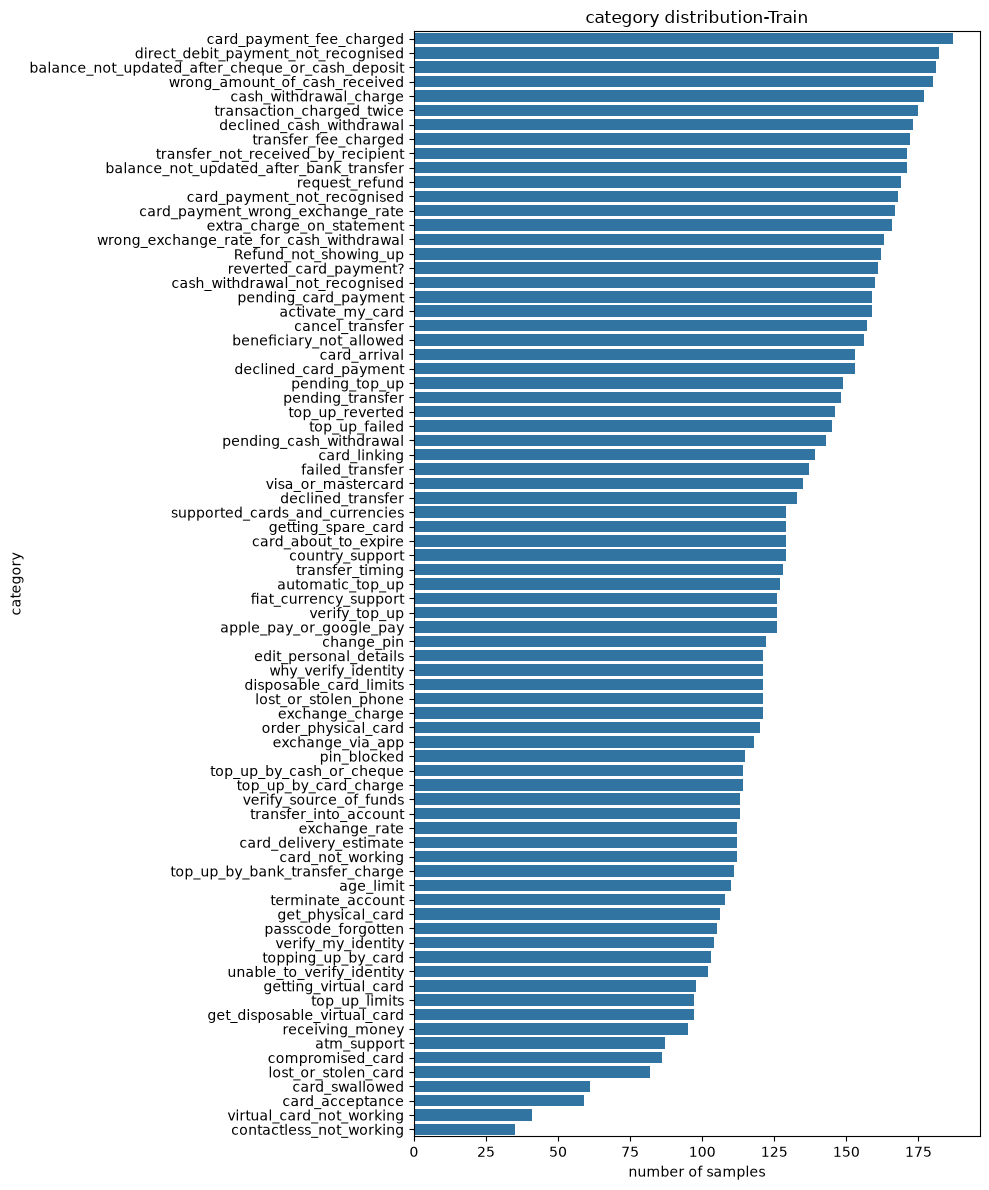

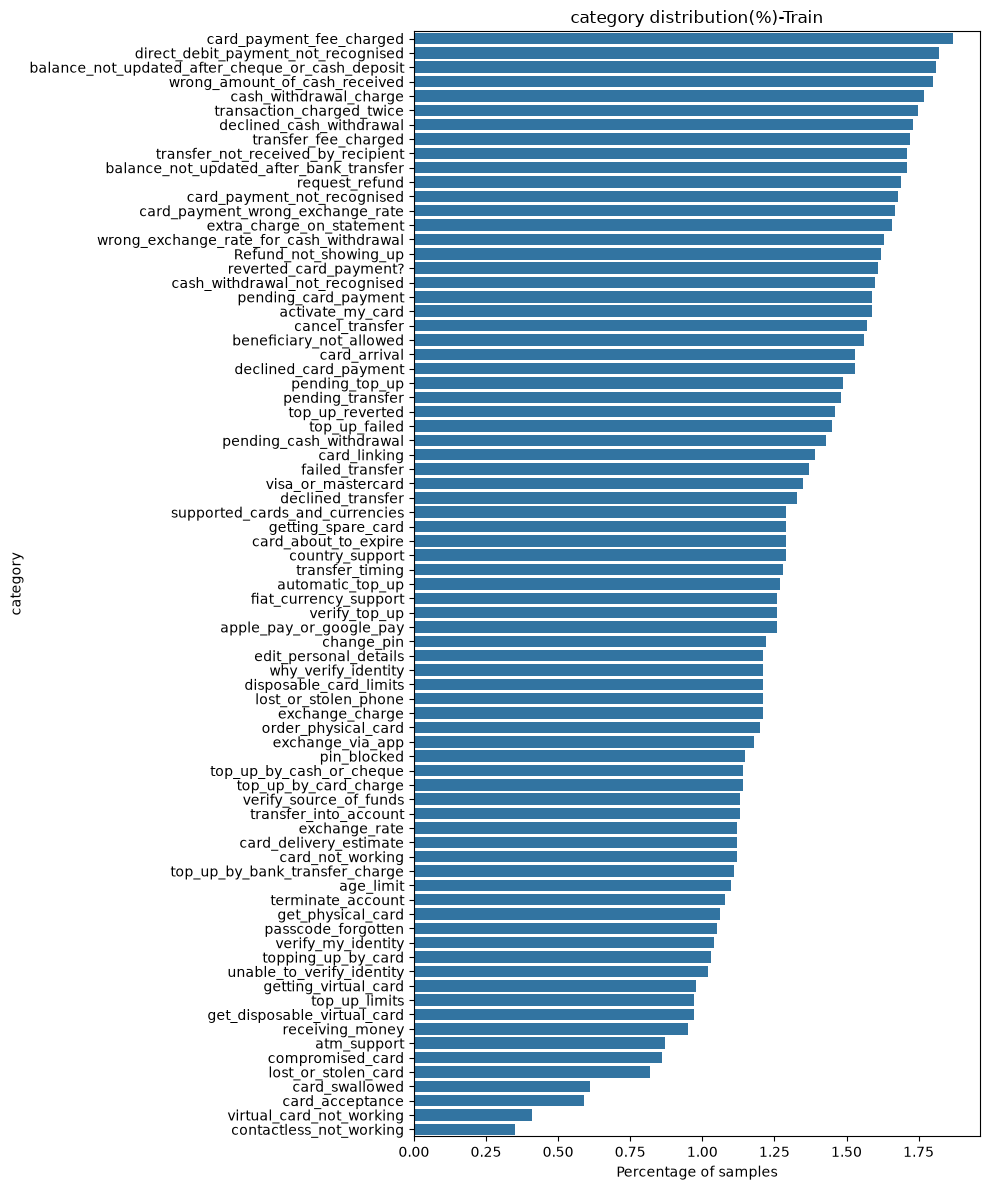

In [45]:
category_counts = train['category'].value_counts()
print(category_counts)
category_percentage = train['category'].value_counts(normalize=True)*100
print(category_percentage.round(2))

plt.figure(figsize=(10,12))
sns.barplot(x=category_counts.values,y=category_counts.index)
plt.title("category distribution-Train")
plt.xlabel("number of samples")
plt.ylabel("category")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,12))
sns.barplot(x=category_percentage.values,y=category_percentage.index)
plt.title("category distribution(%)-Train")
plt.xlabel("Percentage of samples")
plt.ylabel("category")

plt.tight_layout()
plt.show()



In [46]:
print("Largest category:")
print(category_counts.idxmax(),"-",category_counts.max())

print("\nSmallest category:")
print(category_counts.idxmin(),"-",category_counts.min())

Largest category:
card_payment_fee_charged - 187

Smallest category:
contactless_not_working - 35


In [47]:
imbalance_ratio = category_counts.max()/category_counts.min()

print("Imbalance Ratio:",round(imbalance_ratio,2))

Imbalance Ratio: 5.34


# NLP preprocessing

In [64]:
import pandas as pd
import numpy as np
train = pd.read_csv(r"\Users\DIVYA PRIYA\Downloads\FInal_project1_AI_Banking\Data\Raw\train.csv")

In [65]:
test = pd.read_csv(r"\Users\DIVYA PRIYA\Downloads\FInal_project1_AI_Banking\Data\Raw\test.csv")

In [68]:
import re 

train = train.dropna(subset=["text","category"]).copy()
test = test.dropna(subset=["text","category"]).copy()

train["text"] = train["text"].astype(str)
test["text"] = test["text"].astype(str)

train["text"] = train["text"].str.lower()
test["text"] = test["text"].str.lower()

train["text"] = train["text"].str.replace(r"https?://\S+|www\.\S+", "",regex=True)
test["text"] = test["text"].str.replace(r"https?://\S+|www\.\S+", "",regex=True)

train["text"] = train["text"].str.replace(r"<.*?>", "",regex=True)
test["text"] = test["text"].str.replace(r"<.*?>", "",regex=True)

train["text"] = train["text"].str.replace(r"[^a-z0-9\s.,!'-]", "",regex=True)
test["text"] = test["text"].str.replace(r"[^a-z0-9\s.,!'-]", "",regex=True)

train["text"] = train["text"].str.replace(r"\s+", " ",regex=True).str.strip()
test["text"] = test["text"].str.replace(r"\s+", " ",regex=True).str.strip()




In [70]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train[["text","category"]])
print(test[["text","category"]])

Train shape: (10003, 2)
Test shape: (3080, 2)
                                                    text         category
0                          i am still waiting on my card     card_arrival
1      what can i do if my card still hasn't arrived ...     card_arrival
2      i have been waiting over a week. is the card s...     card_arrival
3      can i track my card while it is in the process...     card_arrival
4      how do i know if i will get my card, or if it ...     card_arrival
...                                                  ...              ...
9998               you provide support in what countries  country_support
9999                   what countries are you supporting  country_support
10000                 what countries are getting support  country_support
10001                      are cards available in the eu  country_support
10002                    which countries are represented  country_support

[10003 rows x 2 columns]
                                        

# Training and validation 

In [71]:
from sklearn.model_selection import train_test_split 

X = train["text"]
y = train["category"]

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y) 

print("Training data:",X_train.shape)
print("Validation data:",X_val.shape)
print("Test data:",test['text'].shape)

print("\nTraining category distribution:")
print(y_train.value_counts())

print("\nTraining category distribution:")
print(y_val.value_counts())                                          

Training data: (8002,)
Validation data: (2001,)
Test data: (3080,)

Training category distribution:
category
card_payment_fee_charged                            149
direct_debit_payment_not_recognised                 145
balance_not_updated_after_cheque_or_cash_deposit    145
wrong_amount_of_cash_received                       144
cash_withdrawal_charge                              141
                                                   ... 
lost_or_stolen_card                                  66
card_swallowed                                       49
card_acceptance                                      47
virtual_card_not_working                             33
contactless_not_working                              28
Name: count, Length: 77, dtype: int64

Training category distribution:
category
card_payment_fee_charged                            38
direct_debit_payment_not_recognised                 37
cash_withdrawal_charge                              36
balance_not_updated_after_cheq